# Landslide Dataset Analysis

This notebook performs outlier detection, correlation analysis, normalization/standardization, and PCA on the Landslides dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8,5)

## 2. Read Dataset

In [2]:
df = pd.read_csv('landslide_data_original.csv')
#index_col
attributes = ['temperature','humidity','pressure','rain','lightavgw','lightmax']
df.head()

,dates,stationid,temperature,humidity,pressure,rain,lightavgw,lightmax,moisture
0,08-07-2018,t10,25.46875,82.18750,1036.346875,6.75,5.5000,4000,0.0000
1,09-07-2018,t10,26.19298,83.14912,1037.604386,1761.75,11.8448,4000,5.6930
2,10-07-2018,t10,25.17021,85.34043,1037.889362,652.50,8.7692,4000,6.8511
3,11-07-2018,t10,24.29851,87.68657,1036.857463,963.00,8.8358,4000,6.0373
4,12-07-2018,t10,24.06923,87.64615,1027.830769,254.25,274.6232,4333,31.2385


## 3. Outlier Detection using IQR

In [3]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers = {}
for col in attributes:
    outliers[col] = detect_outliers(df[col])
    print(f"{col}: {len(outliers[col])} outliers")
    print(outliers[col].values)


temperature: 10 outliers
[7.6729 7.6729 7.6729 7.6729 7.6729 7.6729 7.6729 7.6729 7.6729 7.6729]
humidity: 8 outliers
[31.      31.      31.07143 31.      31.      31.      31.      31.     ]
pressure: 132 outliers
[1037.8893617   991.65411215  800.          894.634       894.01007353
  893.80895652  789.39269231  812.45572289  893.67753731  948.46788732
 1053.39953488 1044.14833333  882.735       991.69361702  986.09300699
  990.11549296  987.05306569  588.46619718  452.09788732 1054.75116279
 1055.43955224 1055.29179104 1054.11904762 1053.45777778 1053.31567164
 1053.21804511 1053.41307692 1054.63458647 1052.65757576 1053.54885496
 1054.71791045 1053.05671642 1051.01111111 1051.8761194  1054.95223881
 1052.05373134 1050.31052632 1052.41578947 1055.58358209 1055.83333333
 1055.34365079 1056.08796992 1057.88731343 1055.09618321 1055.10309278
  967.86592    1048.1971179  1048.87515873 1050.87168067 1051.67263158
 1053.28277778 1053.11095238 1054.94553191 1055.16835821 1055.45969697
 105

### Boxplot Before Outlier Correction

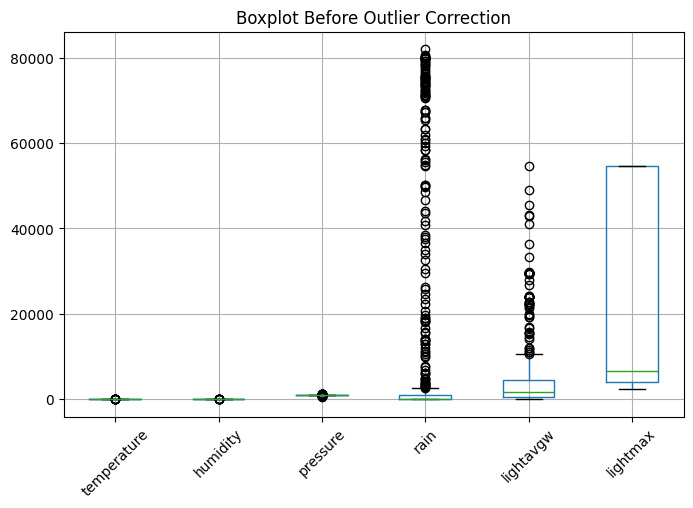

In [4]:
df[attributes].boxplot(rot=45)
plt.title('Boxplot Before Outlier Correction')
plt.show()

## 4. Replace Outliers with Median

In [5]:
df_corrected = df.copy()
for col in attributes:
    median = df[col].median()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_corrected.loc[(df_corrected[col] < lower) | (df_corrected[col] > upper), col] = median

df_corrected.to_csv('landslides_data_corrected.csv', index=False)

### Boxplot After Outlier Correction

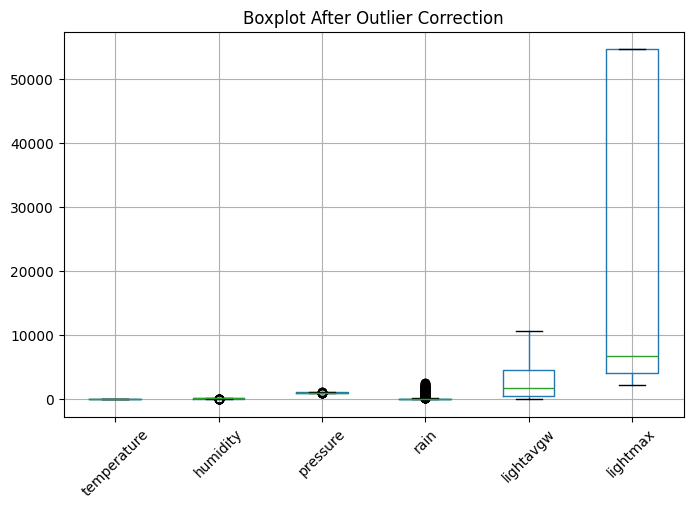

In [6]:
df_corrected[attributes].boxplot(rot=45)
plt.title('Boxplot After Outlier Correction')
plt.show()

## 5. Correlation Analysis

In [7]:
pearson_corr = df_corrected[attributes].corr(method='pearson')
spearman_corr = df_corrected[attributes].corr(method='spearman')

pearson_corr, spearman_corr

(             temperature  humidity  pressure      rain  lightavgw  lightmax
 temperature     1.000000  0.390199 -0.474969  0.078539  -0.082871 -0.184258
 humidity        0.390199  1.000000 -0.434660  0.214362  -0.164206 -0.271069
 pressure       -0.474969 -0.434660  1.000000 -0.155556   0.193551  0.112807
 rain            0.078539  0.214362 -0.155556  1.000000   0.061002 -0.009647
 lightavgw      -0.082871 -0.164206  0.193551  0.061002   1.000000  0.674637
 lightmax       -0.184258 -0.271069  0.112807 -0.009647   0.674637  1.000000,
              temperature  humidity  pressure      rain  lightavgw  lightmax
 temperature     1.000000  0.260195 -0.542347  0.201006  -0.141109 -0.172820
 humidity        0.260195  1.000000 -0.463449  0.291729  -0.143485 -0.251758
 pressure       -0.542347 -0.463449  1.000000 -0.201066   0.172845  0.128289
 rain            0.201006  0.291729 -0.201066  1.000000   0.097869  0.070359
 lightavgw      -0.141109 -0.143485  0.172845  0.097869   1.000000  0.82416

### Correlation Heatmaps

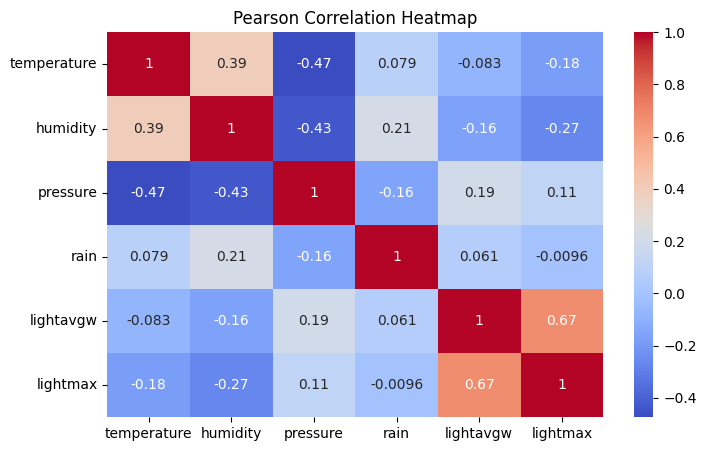

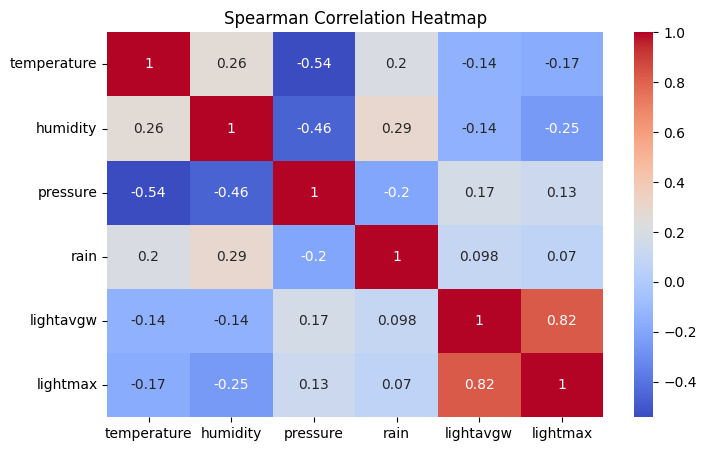

In [8]:
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title('Pearson Correlation Heatmap')
plt.show()

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title('Spearman Correlation Heatmap')
plt.show()

## 6. Target Attribute Correlation (moisture)

In [9]:
target = 'moisture'
attributes_1 = attributes.copy()
attributes_1.append(target)

pearson = df_corrected[attributes_1].corr(method='pearson')[target]
spearman = df_corrected[attributes_1].corr(method='spearman')[target]

pd.DataFrame({

    'Pearson': pearson,

    'Spearman': spearman
})

,Pearson,Spearman
temperature,0.057014,0.061563
humidity,-0.001248,0.039543
pressure,0.093579,0.073985
rain,0.169460,0.390779
lightavgw,-0.066839,0.074309
lightmax,0.005725,0.075334
moisture,1.000000,1.000000


### Bar Plot for Target Correlation

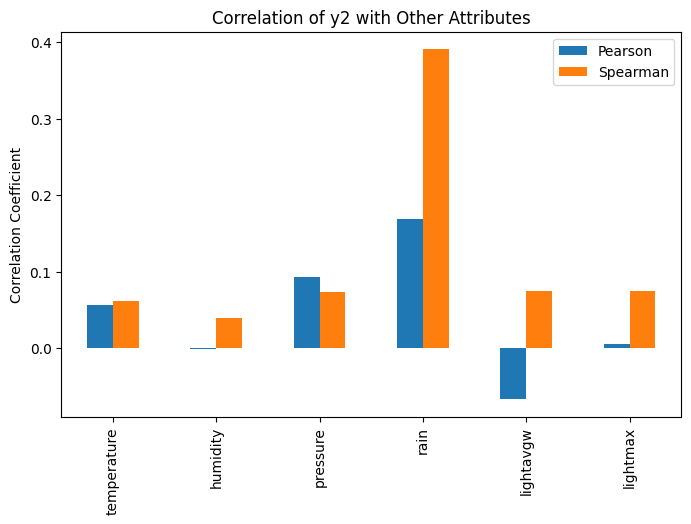

In [10]:
pd.DataFrame({
    'Pearson': pearson,
    'Spearman': spearman
}).drop(target).plot(kind='bar')
plt.title('Correlation of y2 with Other Attributes')
plt.ylabel('Correlation Coefficient')
plt.show()

### Scatter Plots with Target

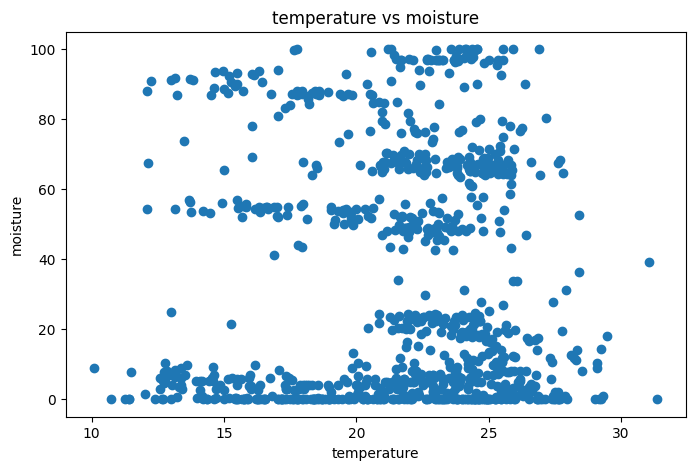

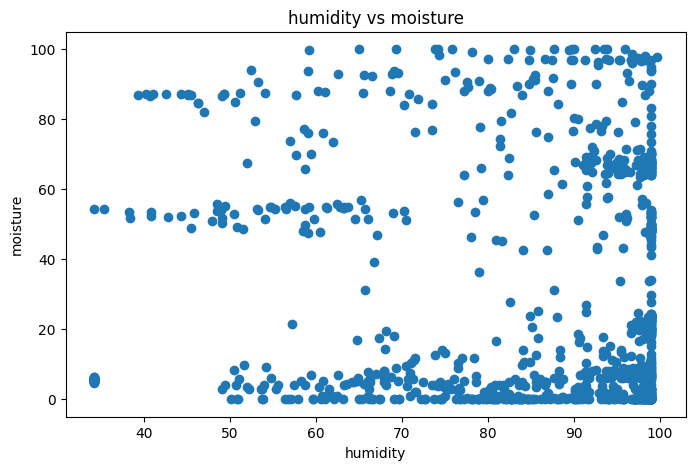

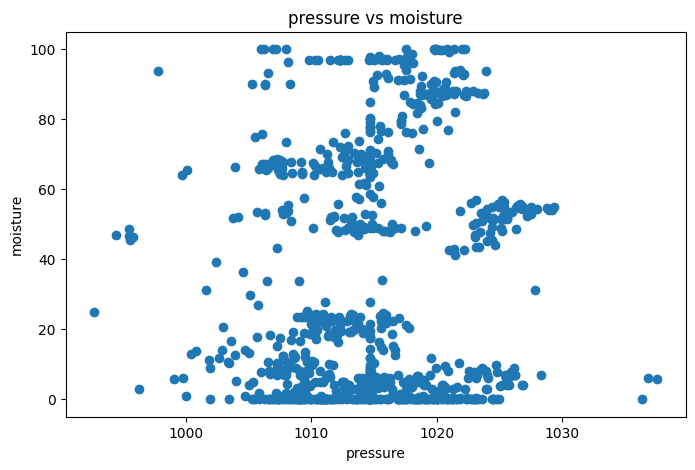

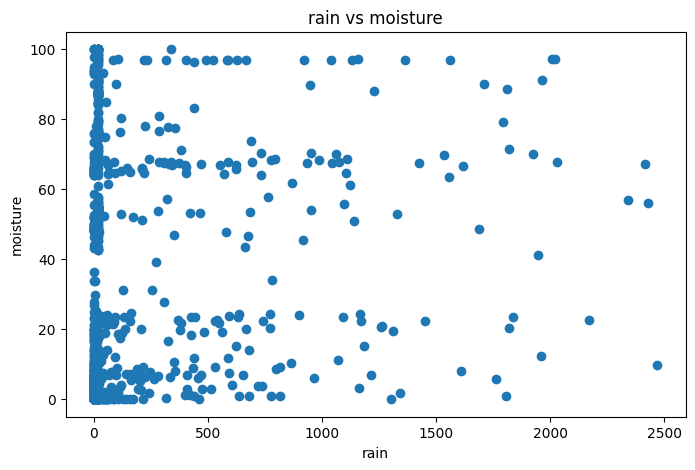

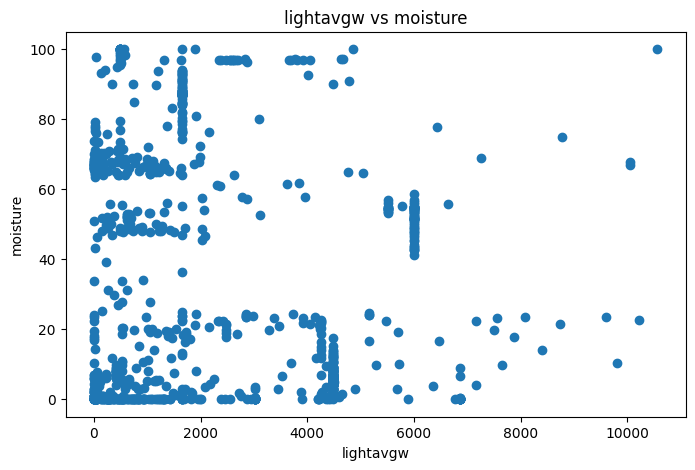

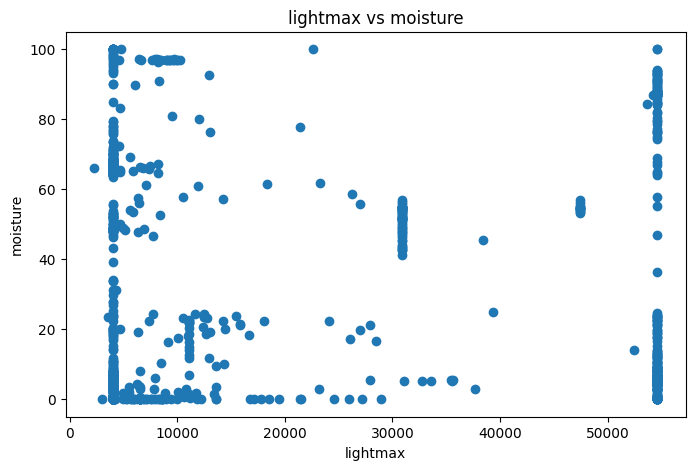

In [11]:
for col in attributes:
    if col != target:
        plt.scatter(df_corrected[col], df_corrected[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{col} vs {target}')
        plt.show()

## 7. Standardization and Normalization

In [12]:
# Min and Max
df_corrected[attributes].agg(['min','max'])

,temperature,humidity,pressure,rain,lightavgw,lightmax
min,10.08511,34.20567,992.654583,0.0,0.0000,2259
max,31.37500,99.72000,1037.604386,2470.5,10565.3523,54612


In [13]:
# Min-Max Normalization (0-1)
scaler_01 = MinMaxScaler(feature_range=(0,1))
norm_01 = scaler_01.fit_transform(df_corrected[attributes])

# Min-Max Normalization (10-30)
scaler_030 = MinMaxScaler(feature_range=(10,30))
norm_030 = scaler_030.fit_transform(df_corrected[attributes])

In [14]:
# Create DataFrames
df_norm_01 = pd.DataFrame(
    norm_01,
    columns=attributes,
    index=df_corrected.index
)

df_norm_030 = pd.DataFrame(
    norm_030,
    columns=attributes,
    index=df_corrected.index
)

In [15]:
df_norm_01.to_csv("landslides_data_normalisation.csv", index=False)
df_norm_030.to_csv("landslides_data_normalisation_30.csv", index=False)

In [16]:
# Standardization
scaler_std = StandardScaler()
standardized = scaler_std.fit_transform(df_corrected[attributes])

mean_before = df_corrected[attributes].mean()
std_before = df_corrected[attributes].std()

mean_after = standardized.mean(axis=0)
std_after = standardized.std(axis=0)

mean_before, std_before, mean_after, std_after

(temperature       21.369384
 humidity          83.991017
 pressure        1014.793130
 rain             171.466677
 lightavgw       2237.899839
 lightmax       21788.623280
 dtype: float64,
 temperature        4.125345
 humidity          17.565356
 pressure           6.120192
 rain             398.459726
 lightavgw       2206.422850
 lightmax       22064.993089
 dtype: float64,
 array([ 1.20303532e-16, -1.20303532e-16, -3.00758830e-17, -3.75948537e-18,
        -1.50379415e-16,  3.75948537e-17]),
 array([1., 1., 1., 1., 1., 1.]))

In [17]:
df_std= pd.DataFrame(
    standardized,
    columns=attributes,
    index=df_corrected.index
)
df_std.to_csv("landslides_data_standardisation.csv", index=False)

## 8. Principal Component Analysis (PCA)

In [18]:
X = df_corrected[attributes].values
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([4.89091777e+08, 2.64189712e+06, 1.57357890e+05, 2.80938321e+02,
        1.08210404e+01, 3.14904367e+01]),
 array([[ 3.43183512e-05, -1.45864867e-04,  7.46246337e-04,
         -9.40840772e-02, -9.17506805e-01, -3.86430938e-01],
        [ 2.15196950e-04, -3.01156896e-04,  9.32312762e-03,
         -9.81893996e-01,  2.15246977e-02,  1.87972896e-01],
        [-3.14372561e-05, -5.93253005e-04, -2.63601586e-03,
          1.64131055e-01, -3.97136628e-01,  9.02959686e-01],
        [ 1.65652032e-04, -2.38535296e-02,  9.99668217e-01,
          9.65998834e-03, -5.54055673e-04,  9.03091728e-04],
        [-6.76737427e-02, -9.97423660e-01, -2.37877273e-02,
         -3.30894913e-05,  3.74434269e-04, -5.56419427e-04],
        [-9.97707466e-01,  6.76504806e-02,  1.78160077e-03,
         -2.16345727e-04, -3.98929904e-05,  3.66916473e-05]]))

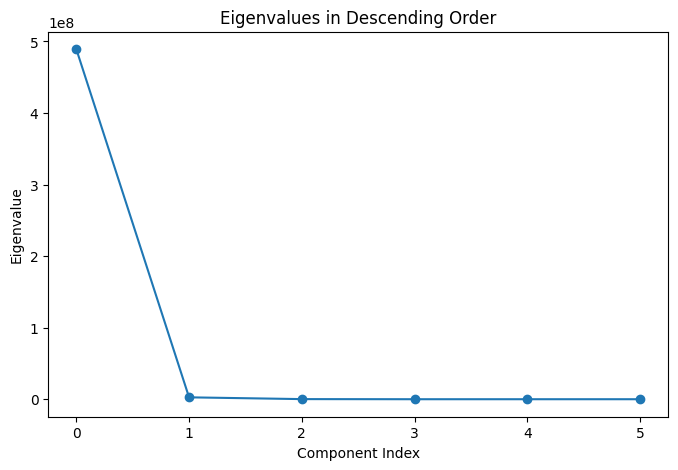

In [19]:
# Sort eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]

plt.plot(eigenvalues_sorted, marker='o')
plt.title('Eigenvalues in Descending Order')
plt.xlabel('Component Index')
plt.ylabel('Eigenvalue')
plt.show()

In [20]:
# PCA using sklearn
pca = PCA()
X_pca = pca.fit_transform(X)
er = pca.explained_variance_ratio_
print('Eigen values:',pca.explained_variance_)
print('explained variance ratio:', er)
print('Eigen vectors:', pca.components_)
cum_var = np.cumsum(er)
print('Cumulative variance:', cum_var)


Eigen values: [4.89091777e+08 2.64189712e+06 1.57357890e+05 2.80938321e+02
 3.14904367e+01 1.08210404e+01]
explained variance ratio: [9.94308543e-01 5.37089561e-03 3.19903753e-04 5.71138968e-07
 6.40190896e-08 2.19988424e-08]
Eigen vectors: [[-3.43183512e-05 -2.15196950e-04  3.14372561e-05 -1.65652032e-04
   6.76737427e-02  9.97707466e-01]
 [ 1.45864867e-04  3.01156896e-04  5.93253005e-04  2.38535296e-02
   9.97423660e-01 -6.76504806e-02]
 [ 7.46246337e-04  9.32312762e-03 -2.63601586e-03  9.99668217e-01
  -2.37877273e-02  1.78160077e-03]
 [ 9.40840772e-02  9.81893996e-01 -1.64131055e-01 -9.65998834e-03
   3.30894913e-05  2.16345727e-04]
 [-3.86430938e-01  1.87972896e-01  9.02959686e-01  9.03091728e-04
  -5.56419427e-04  3.66916473e-05]
 [ 9.17506805e-01 -2.15246978e-02  3.97136628e-01  5.54055673e-04
  -3.74434268e-04  3.98929904e-05]]
Cumulative variance: [0.99430854 0.99967944 0.99999934 0.99999991 0.99999998 1.        ]


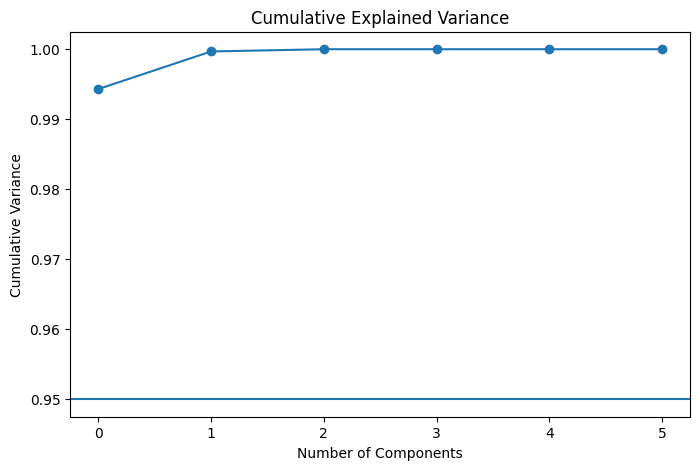

In [21]:
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95)
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

In [22]:
# Retain components with >=95% variance
n_components_95 = np.argmax(cum_var >= 0.95) + 1
pca_95 = PCA(n_components=n_components_95)
X_reduced_95 = pca_95.fit_transform(X)

cov_reduced_95 = np.cov(X_reduced_95, rowvar=False)
cov_reduced_95

array(4.89091777e+08)

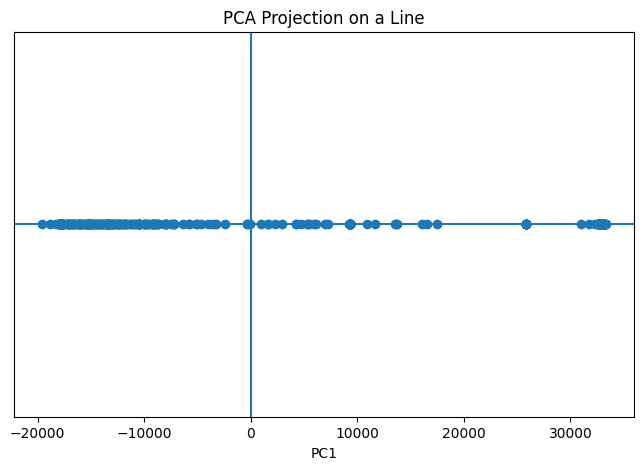

In [23]:
plt.scatter(X_reduced_95[:,0], np.zeros_like(X_reduced_95[:,0]))
plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC1")
plt.yticks([])
plt.title("PCA Projection on a Line")
plt.show()


In [24]:
n_components_95

np.int64(1)

In [25]:
X_reduced_95

array([[-17898.88890665],
       [-17898.75044186],
       [-17898.77598692],
       [-17898.82269251],
       [-17548.48213938],
       [ 32708.77754896],
       [-17890.14101977],
       [-17854.61193804],
       [-15462.78486364],
       [-16272.77298386],
       [ 33026.92756681],
       [ 33081.39944726],
       [-15318.28701809],
       [-17843.08652386],
       [ 32708.8009286 ],
       [-17859.4223378 ],
       [-17841.16188583],
       [-17835.53586713],
       [-16243.78200167],
       [-17668.55401081],
       [-16799.6283284 ],
       [-16451.9394728 ],
       [-17899.26464443],
       [-17887.69637804],
       [-17875.63346687],
       [-17862.3203514 ],
       [ 32782.91230704],
       [ 32708.76327865],
       [-11593.22379232],
       [ 32885.70221868],
       [ -9988.57661012],
       [ 32905.15906356],
       [ -8141.44694329],
       [ -7188.37162624],
       [ -7218.39117875],
       [-14376.6002111 ],
       [ 32708.47358623],
       [ -8867.60836409],
       [ 330

In [26]:
pca.explained_variance_

array([4.89091777e+08, 2.64189712e+06, 1.57357890e+05, 2.80938321e+02,
       3.14904367e+01, 1.08210404e+01])

In [27]:
print('Eigen vectors:', pca.components_)

Eigen vectors: [[-3.43183512e-05 -2.15196950e-04  3.14372561e-05 -1.65652032e-04
   6.76737427e-02  9.97707466e-01]
 [ 1.45864867e-04  3.01156896e-04  5.93253005e-04  2.38535296e-02
   9.97423660e-01 -6.76504806e-02]
 [ 7.46246337e-04  9.32312762e-03 -2.63601586e-03  9.99668217e-01
  -2.37877273e-02  1.78160077e-03]
 [ 9.40840772e-02  9.81893996e-01 -1.64131055e-01 -9.65998834e-03
   3.30894913e-05  2.16345727e-04]
 [-3.86430938e-01  1.87972896e-01  9.02959686e-01  9.03091728e-04
  -5.56419427e-04  3.66916473e-05]
 [ 9.17506805e-01 -2.15246978e-02  3.97136628e-01  5.54055673e-04
  -3.74434268e-04  3.98929904e-05]]


In [28]:
df_reduced_95= pd.DataFrame(
    X_reduced_95,
    columns=['c1'],
    index=df_corrected.index
)
df_reduced_95.to_csv("landslides_data_pca_all.csv", index=False)

In [29]:
df_reduced_95

,c1
0,-17898.888907
1,-17898.750442
2,-17898.775987
3,-17898.822693
4,-17548.482139
...,...
940,25834.743638
941,25834.742738
942,25834.743635
943,25834.744514


In [30]:
n_components = len(cum_var)
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X)
cov_reduced = np.cov(X_reduced, rowvar=False)
cov_reduced

array([[ 4.89091777e+08,  1.01024822e-08,  0.00000000e+00,
        -2.10968241e-08, -1.12765011e-08,  1.46459477e-09],
       [ 1.01024822e-08,  2.64189712e+06, -2.93356745e-08,
         1.02677327e-08,  2.76104093e-09,  2.41493966e-10],
       [ 0.00000000e+00, -2.93356745e-08,  1.57357890e+05,
         1.19648074e-09, -9.81098141e-11,  6.75954961e-12],
       [-2.10968241e-08,  1.02677327e-08,  1.19648074e-09,
         2.80938321e+02, -1.85313688e-09,  2.50868265e-09],
       [-1.12765011e-08,  2.76104093e-09, -9.81098141e-11,
        -1.85313688e-09,  3.14904367e+01, -1.01206930e-08],
       [ 1.46459477e-09,  2.41493966e-10,  6.75954961e-12,
         2.50868265e-09, -1.01206930e-08,  1.08210404e+01]])

In [31]:
pca.explained_variance_

array([4.89091777e+08, 2.64189712e+06, 1.57357890e+05, 2.80938321e+02,
       3.14904367e+01, 1.08210404e+01])

In [32]:
pca.components_

array([[-3.43183512e-05, -2.15196950e-04,  3.14372561e-05,
        -1.65652032e-04,  6.76737427e-02,  9.97707466e-01],
       [ 1.45864867e-04,  3.01156896e-04,  5.93253005e-04,
         2.38535296e-02,  9.97423660e-01, -6.76504806e-02],
       [ 7.46246337e-04,  9.32312762e-03, -2.63601586e-03,
         9.99668217e-01, -2.37877273e-02,  1.78160077e-03],
       [ 9.40840772e-02,  9.81893996e-01, -1.64131055e-01,
        -9.65998834e-03,  3.30894913e-05,  2.16345727e-04],
       [-3.86430938e-01,  1.87972896e-01,  9.02959686e-01,
         9.03091728e-04, -5.56419427e-04,  3.66916473e-05],
       [ 9.17506805e-01, -2.15246978e-02,  3.97136628e-01,
         5.54055673e-04, -3.74434268e-04,  3.98929904e-05]])

In [33]:
df_reduced= pd.DataFrame(
    X_reduced,
    columns=['c1','c2','c3','c4','c5','c6'],
    index=df_corrected.index
)
df_reduced.to_csv("landslides_data_pca_select.csv", index=False)

In [34]:
pca = PCA(n_components=n_components)
pca.fit(X)
pca.components_

array([[-3.43183512e-05, -2.15196950e-04,  3.14372561e-05,
        -1.65652032e-04,  6.76737427e-02,  9.97707466e-01],
       [ 1.45864867e-04,  3.01156896e-04,  5.93253005e-04,
         2.38535296e-02,  9.97423660e-01, -6.76504806e-02],
       [ 7.46246337e-04,  9.32312762e-03, -2.63601586e-03,
         9.99668217e-01, -2.37877273e-02,  1.78160077e-03],
       [ 9.40840772e-02,  9.81893996e-01, -1.64131055e-01,
        -9.65998834e-03,  3.30894913e-05,  2.16345727e-04],
       [-3.86430938e-01,  1.87972896e-01,  9.02959686e-01,
         9.03091728e-04, -5.56419427e-04,  3.66916473e-05],
       [ 9.17506805e-01, -2.15246978e-02,  3.97136628e-01,
         5.54055673e-04, -3.74434268e-04,  3.98929904e-05]])

In [35]:
pca.explained_variance_

array([4.89091777e+08, 2.64189712e+06, 1.57357890e+05, 2.80938321e+02,
       3.14904367e+01, 1.08210404e+01])

In [36]:
X_reduced_transform = pca.transform(X)

In [37]:
X_reduced

array([[-1.78988889e+04, -1.02715574e+03, -1.43321105e+02,
        -7.25401713e+00,  1.79797306e+01,  1.23947816e+01],
       [-1.78987504e+04, -9.78963197e+02,  1.61095188e+03,
        -2.34011359e+01,  2.05975015e+01,  1.45079646e+01],
       [-1.78987760e+04, -1.00850349e+03,  5.02223172e+02,
        -6.86752839e+00, -2.97158612e-01,  3.80398996e+00],
       ...,
       [ 2.58347436e+04,  1.53442321e+03, -1.86053479e+02,
        -2.00911818e+01,  9.58082911e+00,  9.15998126e-01],
       [ 2.58347445e+04,  1.53442044e+03, -1.86088875e+02,
        -2.40956682e+01,  6.12740944e+00,  7.11516858e-01],
       [ 2.58525191e+04,  1.79637741e+03, -1.92384091e+02,
        -2.90935708e+01,  4.48644337e+00,  1.92948107e+00]])

In [38]:
X_pca

array([[-1.78988889e+04, -1.02715574e+03, -1.43321105e+02,
        -7.25401713e+00,  1.79797306e+01,  1.23947816e+01],
       [-1.78987504e+04, -9.78963197e+02,  1.61095188e+03,
        -2.34011359e+01,  2.05975015e+01,  1.45079646e+01],
       [-1.78987760e+04, -1.00850349e+03,  5.02223172e+02,
        -6.86752839e+00, -2.97158612e-01,  3.80398996e+00],
       ...,
       [ 2.58347436e+04,  1.53442321e+03, -1.86053479e+02,
        -2.00911818e+01,  9.58082911e+00,  9.15998126e-01],
       [ 2.58347445e+04,  1.53442044e+03, -1.86088875e+02,
        -2.40956682e+01,  6.12740944e+00,  7.11516858e-01],
       [ 2.58525191e+04,  1.79637741e+03, -1.92384091e+02,
        -2.90935708e+01,  4.48644337e+00,  1.92948107e+00]])